## Imports & Config

In [9]:
import importlib

from meta_heuristics import meta_information
from meta_heuristics import  problem_instance
from meta_heuristics import  solution_instance
from meta_heuristics import  swap_2_player
from meta_heuristics import  simulated_annealing
importlib.reload(meta_information)
importlib.reload(problem_instance)
importlib.reload(solution_instance)
importlib.reload(swap_2_player)
importlib.reload(simulated_annealing)

from meta_information import MetaInformationPlotter, MetaInformation
from problem_instance import ProblemInstance
from solution_instance import SolutionInstance
from swap_2_player import Swap2Player
from simulated_annealing import SimulatedAnnealing

# Social Golfer Problem Config
NUM_GROUPS = 6
NUM_PLAYERS = 32
NUM_WEEKS = 8

# Simulated Annealing Config
# INIT_TEMP = 400
# FINAL_TEMP = 0.001
# EQI_ITER = 20
# ALPHA = 0.90

## Run Simulated Annealing

Violation Count: 132
Week 0:
  Group 0: [30, 2, 31, 8, 27]
  Group 1: [5, 18, 11, 1, 13]
  Group 2: [15, 20, 16, 6, 4]
  Group 3: [24, 10, 19, 25, 29]
  Group 4: [28, 12, 22, 17, 23]
  Group 5: [3, 7, 0, 21, 26]
Week 1:
  Group 0: [21, 29, 25, 8, 27]
  Group 1: [31, 7, 9, 5, 23]
  Group 2: [19, 15, 17, 14, 28]
  Group 3: [13, 11, 4, 24, 16]
  Group 4: [3, 6, 30, 1, 2]
  Group 5: [26, 12, 22, 18, 20]
Week 2:
  Group 0: [30, 19, 2, 18, 26]
  Group 1: [5, 17, 10, 23, 31]
  Group 2: [1, 15, 16, 11, 9]
  Group 3: [21, 6, 25, 3, 14]
  Group 4: [28, 13, 12, 24, 20]
  Group 5: [27, 29, 8, 22, 7]
Week 3:
  Group 0: [22, 19, 15, 20, 8]
  Group 1: [0, 23, 24, 1, 7]
  Group 2: [3, 12, 11, 9, 14]
  Group 3: [16, 26, 17, 4, 31]
  Group 4: [18, 2, 29, 30, 10]
  Group 5: [6, 21, 25, 13, 27]
Week 4:
  Group 0: [28, 23, 9, 8, 17]
  Group 1: [29, 3, 0, 25, 1]
  Group 2: [22, 14, 16, 30, 31]
  Group 3: [27, 2, 13, 12, 24]
  Group 4: [7, 4, 11, 6, 5]
  Group 5: [21, 20, 10, 15, 19]
Week 5:
  Group 0: [1, 3

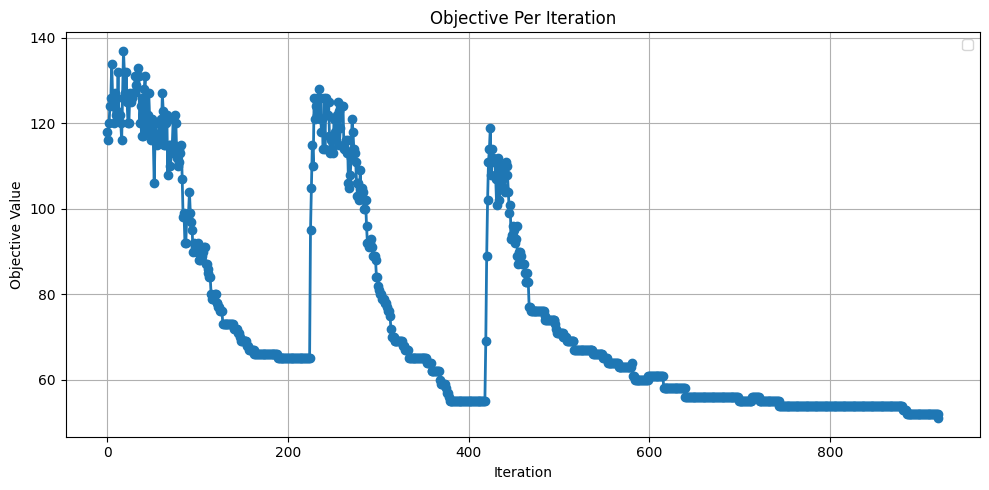

In [10]:
problem_instance = ProblemInstance(NUM_GROUPS,NUM_PLAYERS,NUM_WEEKS)
neighborhood = Swap2Player()
solution_instance = SolutionInstance(problem_instance, SolutionInstance.generate_random_solution, neighborhood)
print(solution_instance)
sa_solver = SimulatedAnnealing(
    solution_instance,
    init_temperature=100,
    final_temperature=0.001,
    equilibrium_iterations=20,
    alpha=0.95,
    max_reheats=10,
    reheat_factor=0.2,
    no_improvement_threshold=5
)


meta_infos = []
best_solution = sa_solver.solve()
print(f"Best solution found with {best_solution.count_violations()} violations: \n{best_solution}")
meta_infos.append(sa_solver.meta_inf)

MetaInformationPlotter.plot_meta_info(meta_infos=meta_infos)